In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'  # For sharper figures, but it takes more time
import matplotlib.cm as cm
import multiprocessing as mp
import scipy as sp
import time
from datetime import datetime

# LISA modules
from lisatools.utils.constants import *
from lisatools.sensitivity  import AE1SensitivityMatrix
from bbhx.waveformbuild import BBHWaveformFD

# Immports for generating simulated LISA data
import noise_generation as noise_generation
from tools.LISASimulator import LISASimulator
from tools.likelihood import get_dh, get_hh
import tools.likelihood as likelihood

# Imports for MCMC
from tools.save_and_load_DE import load_de_results
from tools.time_freq_likelihood import TimeFreqLikelihood
from eryn.ensemble import EnsembleSampler
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.state import State
from scipy.stats import truncnorm
from copy import deepcopy
# Imports for plotting
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import pandas as pd
import corner
import pickle

param_labels = [
    r"$M_T \, [\mathrm{M_\odot}]$",
    r"$q$",
    r"$a_1$",
    r"$a_2$",
    r"$d_L \, [\mathrm{Gpc}]$",
    r"$\phi$",
    r"$\cos(\iota)$",
    r"$\lambda$",
    r"$\sin(\beta)$",
    r"$\psi$",
    r"$t_{\mathrm{c}} \, [\mathrm{s}]$"
]
from tools.MBHB_differential_evolution import MBHB_finder_time_frequency, MBHB_finder_lisatools, MBHB_finder_frequency_domain, transform_bbhx_to_parameters, transform_parameters_to_bbhx

from matplotlib import rc
rc('font', **{
'family': 'serif',
'serif': ['Computer Modern Roman'],
'size' : 16
})
rc('text', usetex=True)

import matplotlib.pyplot as plt

# customized settings
plot_parameter = { # 'backend': 'ps',
"font.family": "DeJavu Serif",
"font.serif": "Times",
"font.size": 16,
"mathtext.fontset": "cm",
"axes.labelsize": "medium",
"axes.titlesize": "medium",
"legend.fontsize": "medium",
"xtick.labelsize": "medium",
"ytick.labelsize": "medium",
"grid.color": "k",
"grid.linestyle": ":",
"grid.linewidth": 0.5,
"savefig.dpi": 150,
}

# tell matplotlib about your param_plots
plt.rcParams.update(plot_parameter)
# set nice figure sizes
fig_width_pt = 1.5*464.0 # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.0) - 1.0) / 2.0 # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1.0 / 72.27 # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt # width in inches
fig_height = fig_width * ratio # height in inches
fig_size = [fig_width, fig_height]
fig_size_squared = [fig_width, fig_width]
plt.rcParams.update({"figure.figsize": fig_size})
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
 


No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.


In [2]:
Tobs = 1.5*YRSID_SI/12
dt = 5.
include_T_channel = False

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False)
sim = LISASimulator(Tobs=Tobs, dt=dt, wave_gen=wave_gen, include_T_channel=include_T_channel)

m1 = 2e5
m2 = 1e5
a1 = 0.2
a2 = 0.4
dist = 6.6 * PC_SI * 1e9
phi_ref = 0.80 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 1.51
beta = -0.17
psi = 1.37
t_ref = Tobs - (24*60*60)
parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waveform_kwargs = dict(length=1024, direct=False, fill=True, squeeze=False, modes=modes)

data_t, data_f, f_array, t_array, sens_mat = sim(seed = 42, parameters=parameters, waveform_kwargs=waveform_kwargs)
waveform_kwargs.update(freqs=f_array)

print(f"SNR of the Signal: {sim.SNR_optimal()[0]}")

hours_before_merger = 14
time_before_merger = hours_before_merger*60*60
cutoff_time = t_ref - time_before_merger
width_of_tref_prior = 20
max_time = t_ref + (width_of_tref_prior - hours_before_merger)*60*60
nperseg = 1414

nwalkers = 24
ntemps = 4
ndims = 11
nleaves_max = 1
nsteps = 2000
perturb_frac = 0.02

analysis = TimeFreqLikelihood(data_t=data_t, wave_gen=wave_gen, nperseg=nperseg)
analysis.pre_merger(time_before_merger=time_before_merger, t_ref=t_ref, t_array=t_array)
analysis.get_stft_of_data()
analysis.pre_merger_SNR()

SNR of the Signal: 2240.644732601064
181.48219636999357


In [3]:
def DE_to_MCMC_params(found_parameters_DE, cutoff_time):
        mT, q, a1, a2, dist_Gpc, phi_ref, cos_inc, lam, sin_beta, psi, t_ref_01 = found_parameters_DE
        mT_exp = np.exp(mT)
        dist_Mpc = dist_Gpc 
        phi_ref = phi_ref % (2*np.pi)
        time_to_coalescence = t_ref_01 * (60*60*24) + cutoff_time
        return np.array([mT_exp, q, a1, a2, dist_Mpc, phi_ref, cos_inc, lam, sin_beta, psi, time_to_coalescence])

In [4]:

x0 =  np.array([12.6049,
                0.510624,
                0.0999252,
                0.339672,
                6.70534,
                1.26919,
                0.903583,
                6.22283,
                -0.311368, 
                0.90331, 
                0.578894])

print(DE_to_MCMC_params(x0, cutoff_time))
print(DE_to_MCMC_params(x0, cutoff_time)[-1] - cutoff_time)

[ 2.98015268e+05  5.10624000e-01  9.99252000e-02  3.39672000e-01
  6.70534000e+00  1.26919000e+00  9.03583000e-01  6.22283000e+00
 -3.11368000e-01  9.03310000e-01  3.85798516e+06]
50016.44160000002


In [5]:
injection_parameters

NameError: name 'injection_parameters' is not defined

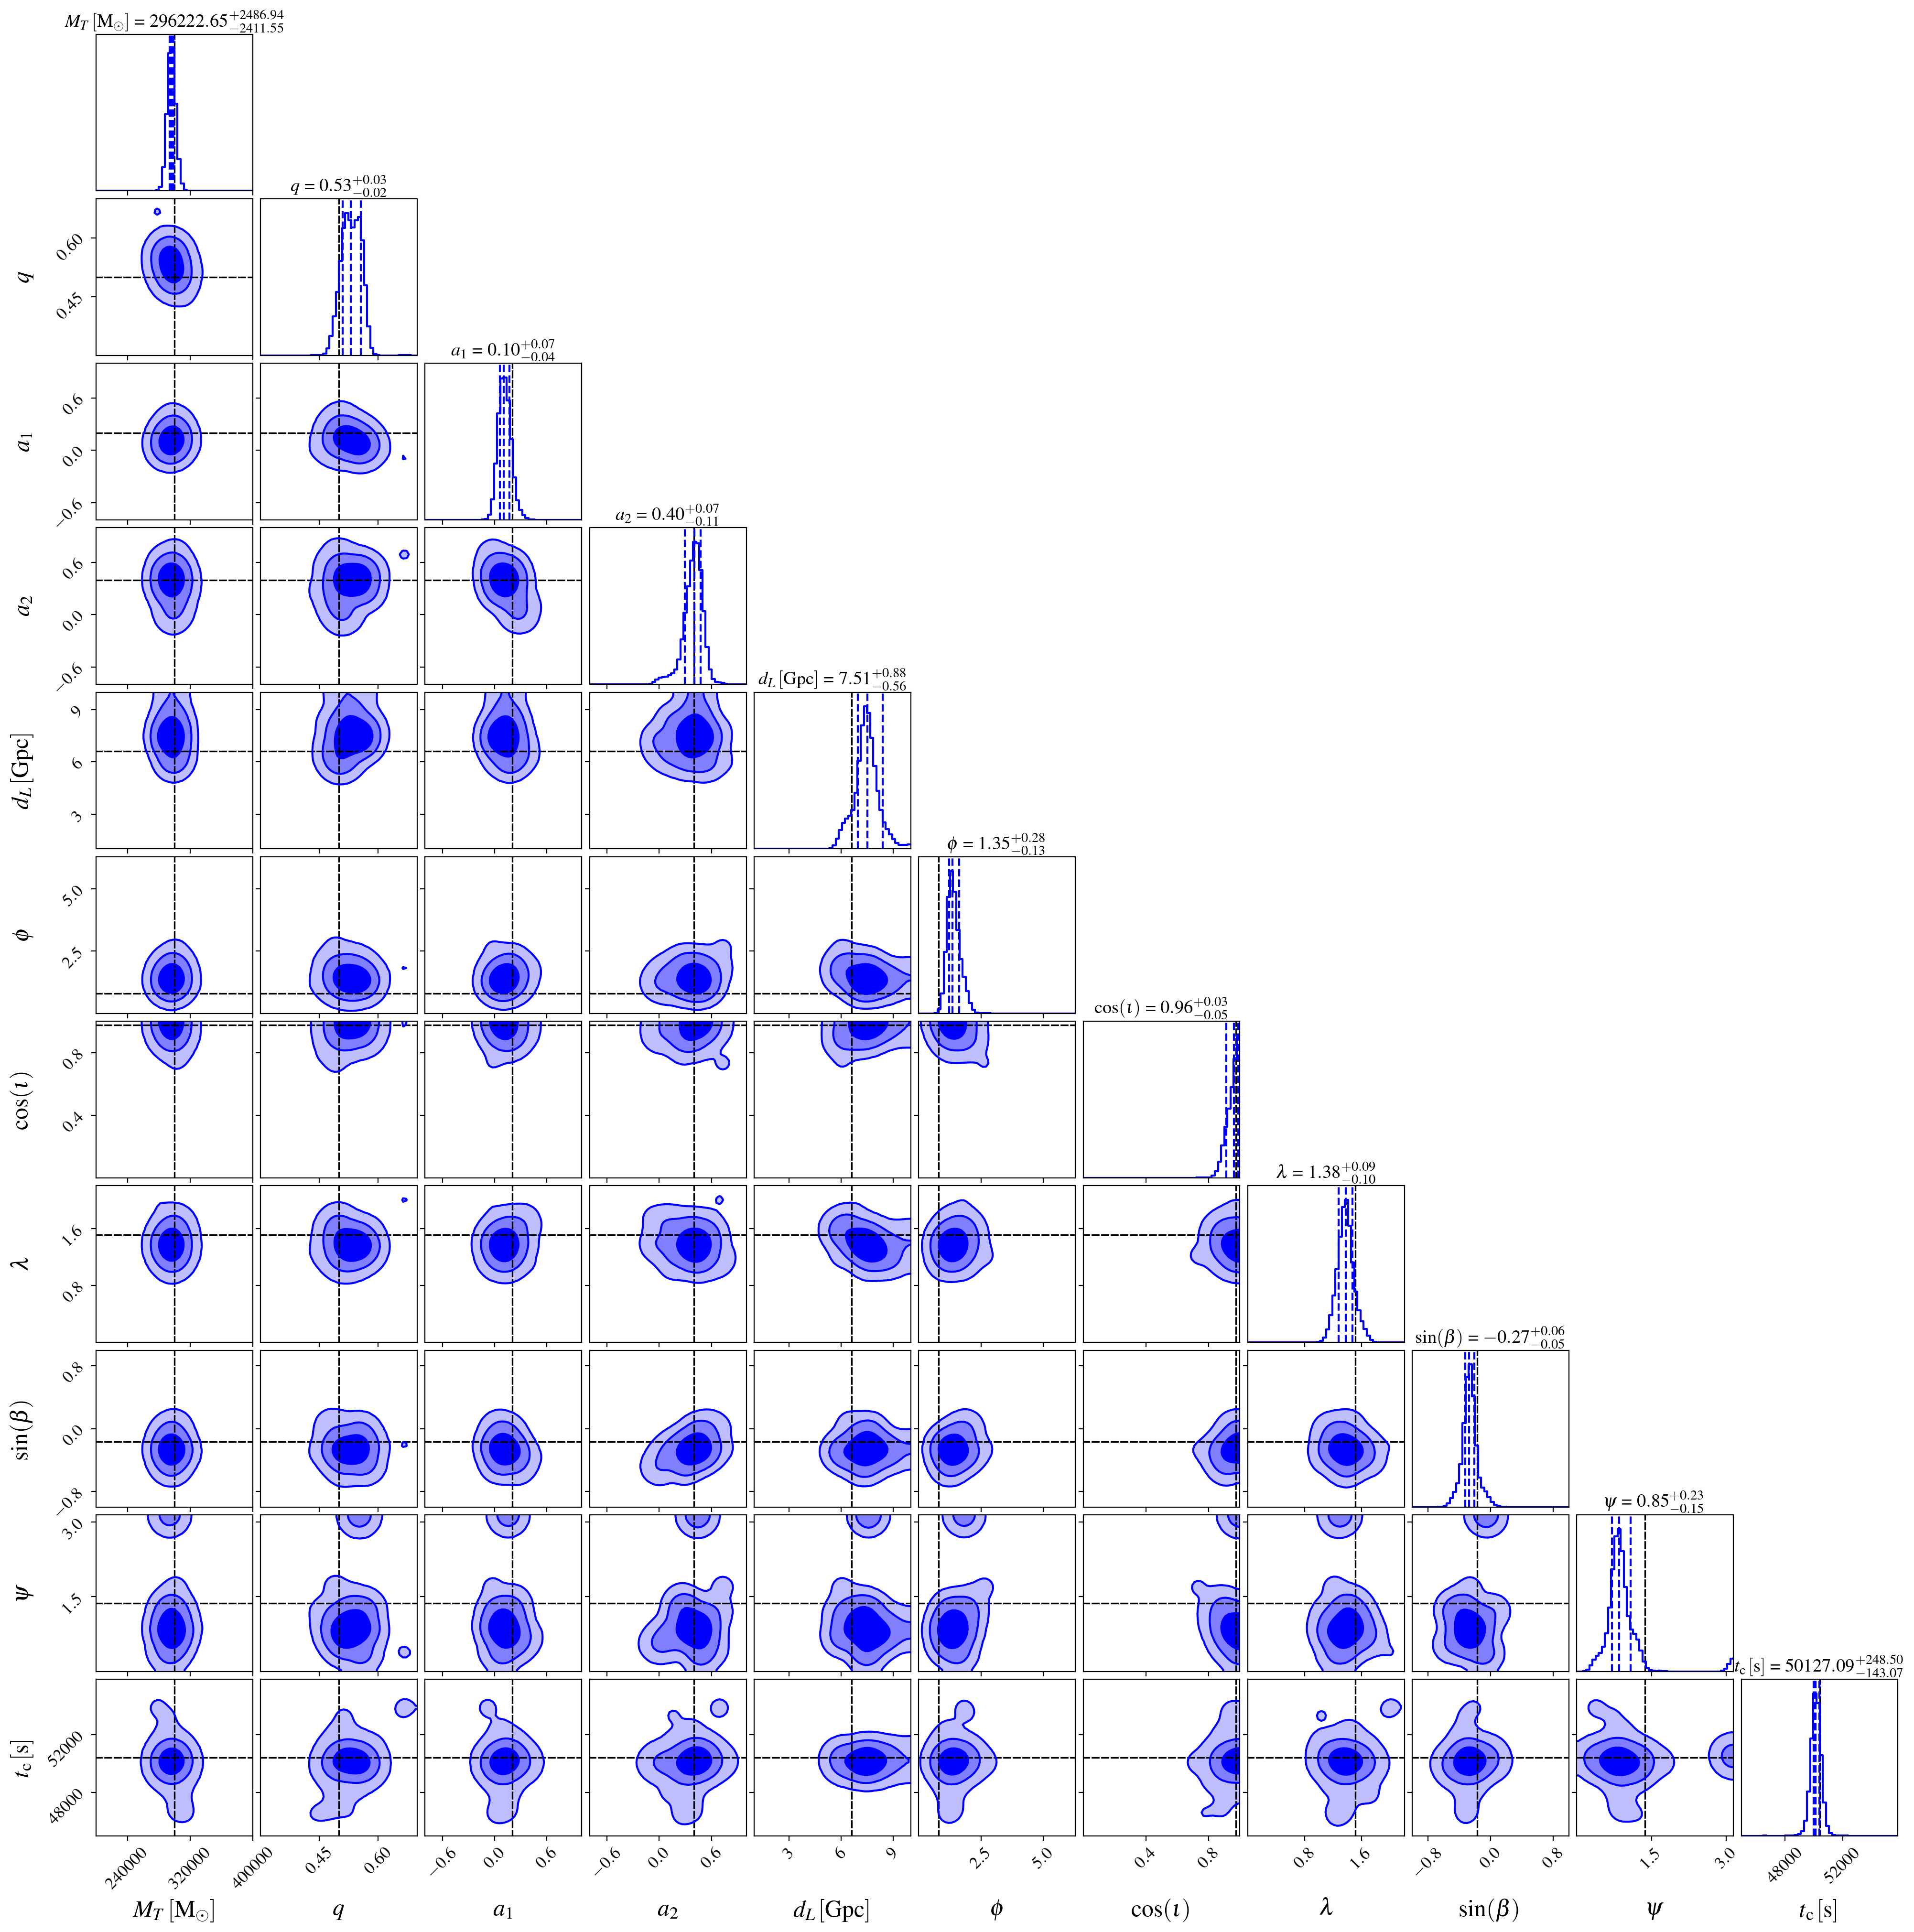

In [6]:
bruh = np.load(f"../mcmc_results/COMPLETELY_NEW_INPUTS/new_original_mcmc_14hours_2000_002.npy")
#bruh = np.load(f"mcmc_results/higher_masses/mcmc_high_masses.npy")
injection_parameters = np.array([m1+m2, m2/m1, a1, a2, dist / (PC_SI * 1e9), phi_ref, np.cos(inc), lam, np.sin(beta), psi, t_ref-cutoff_time])

burnin = 500
bruh_post_burnin = bruh[burnin:]

samples_bruh = bruh[:, 0].reshape(-1, 11)
samples_bruh[:, 10] = samples_bruh[:, 10] - cutoff_time
df_bruh = pd.DataFrame(samples_bruh, columns=param_labels)

nparams = len(param_labels)
fig , axs = plt.subplots(nparams,nparams, figsize=(20,20))
for ax in axs.flatten('C'):
    ax.tick_params(which='both',labelsize=13)

## for all ax tick labels, max significant digits = 3, need to set this with rcparams
for i in range(nparams):
    axs[i,i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
    axs[i,i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.3f}'))

# for all axes when i==j, draw dashed vline at injection and for i<=j draw dashed vline and hline at injections
for i in range(nparams):
    for j in range(nparams):
        if i==j:
            axs[i,j].axvline(injection_parameters[i], color='k', linestyle=(1,(5,1)), linewidth=1.2)
        if i>j:
            axs[i,j].axvline(injection_parameters[j], color='k', linestyle=(1,(5,1)), linewidth=1.2)
            axs[i,j].axhline(injection_parameters[i], color='k', linestyle=(1,(5,1)), linewidth=1.2)

## list of fractional/decimal values of 1, 2 and 3 sigma
levels = [0.6827, 0.9545, 0.9973]
ranges_plot = np.array([
    (2e5, 4e5),
    (0.3, 0.7),
    (-0.8, 1),
    (-0.8, 1),
    (1.0, 10.0),
    (0, 2*np.pi),
    (0.0, 1.0),
    (0.0, 2.2),
    (-1.0, 1.0),
    (0.0, np.pi),
    (injection_parameters[-1]-1.5*3600, injection_parameters[-1]+1.5*3600)
])
corner.corner(  
                df_bruh.values, 
                labels=param_labels, 
                fig=fig,
                show_titles=True,
                title_kwargs={"fontsize":14},
                levels=levels,
                color = 'blue',
                alpha=0.6,
                smooth=2.5,
                labelpad=0.1,
                label_kwargs={"fontsize":18},
                quantiles=[0.16, 0.5, 0.84],
                bins=50,
                fill_contours=True,
                plot_datapoints=False,
                max_n_ticks=3,
                smooth1d=1.2,
                range=ranges_plot,
                #hist_kwargs={"density": True, "linewidth": 1.5, "histtype": "stepfilled", "alpha": 0.2, },
                    );

# save figure as pdf
#plt.savefig("COMPL_NEW_14_hours/corner_different_inputs.pdf", bbox_inches='tight', dpi=300)

plt.show()

In [7]:
q_low, q_med, q_high = 0.16, 0.5, 0.84

# compute median and uncertainties
medians = np.percentile(samples_bruh, 50, axis=0)
lower_err = medians - np.percentile(samples_bruh, 16, axis=0)
upper_err = np.percentile(samples_bruh, 84, axis=0) - medians

# print nicely
for i, label in enumerate(param_labels):
    print(f"{medians[i]:.3f} +{upper_err[i]:.3f} -{lower_err[i]:.3f}")

296222.648 +2486.940 -2411.548
0.531 +0.025 -0.021
0.104 +0.066 -0.044
0.405 +0.069 -0.109
7.507 +0.879 -0.559
1.348 +0.278 -0.128
0.962 +0.027 -0.048
1.376 +0.095 -0.098
-0.274 +0.065 -0.048
0.848 +0.233 -0.145
50127.092 +248.496 -143.071


In [8]:
injection_parameters

array([ 3.00000000e+05,  5.00000000e-01,  2.00000000e-01,  4.00000000e-01,
        6.60000000e+00,  8.00000000e-01,  9.75016726e-01,  1.51000000e+00,
       -1.69182349e-01,  1.37000000e+00,  5.04000000e+04])

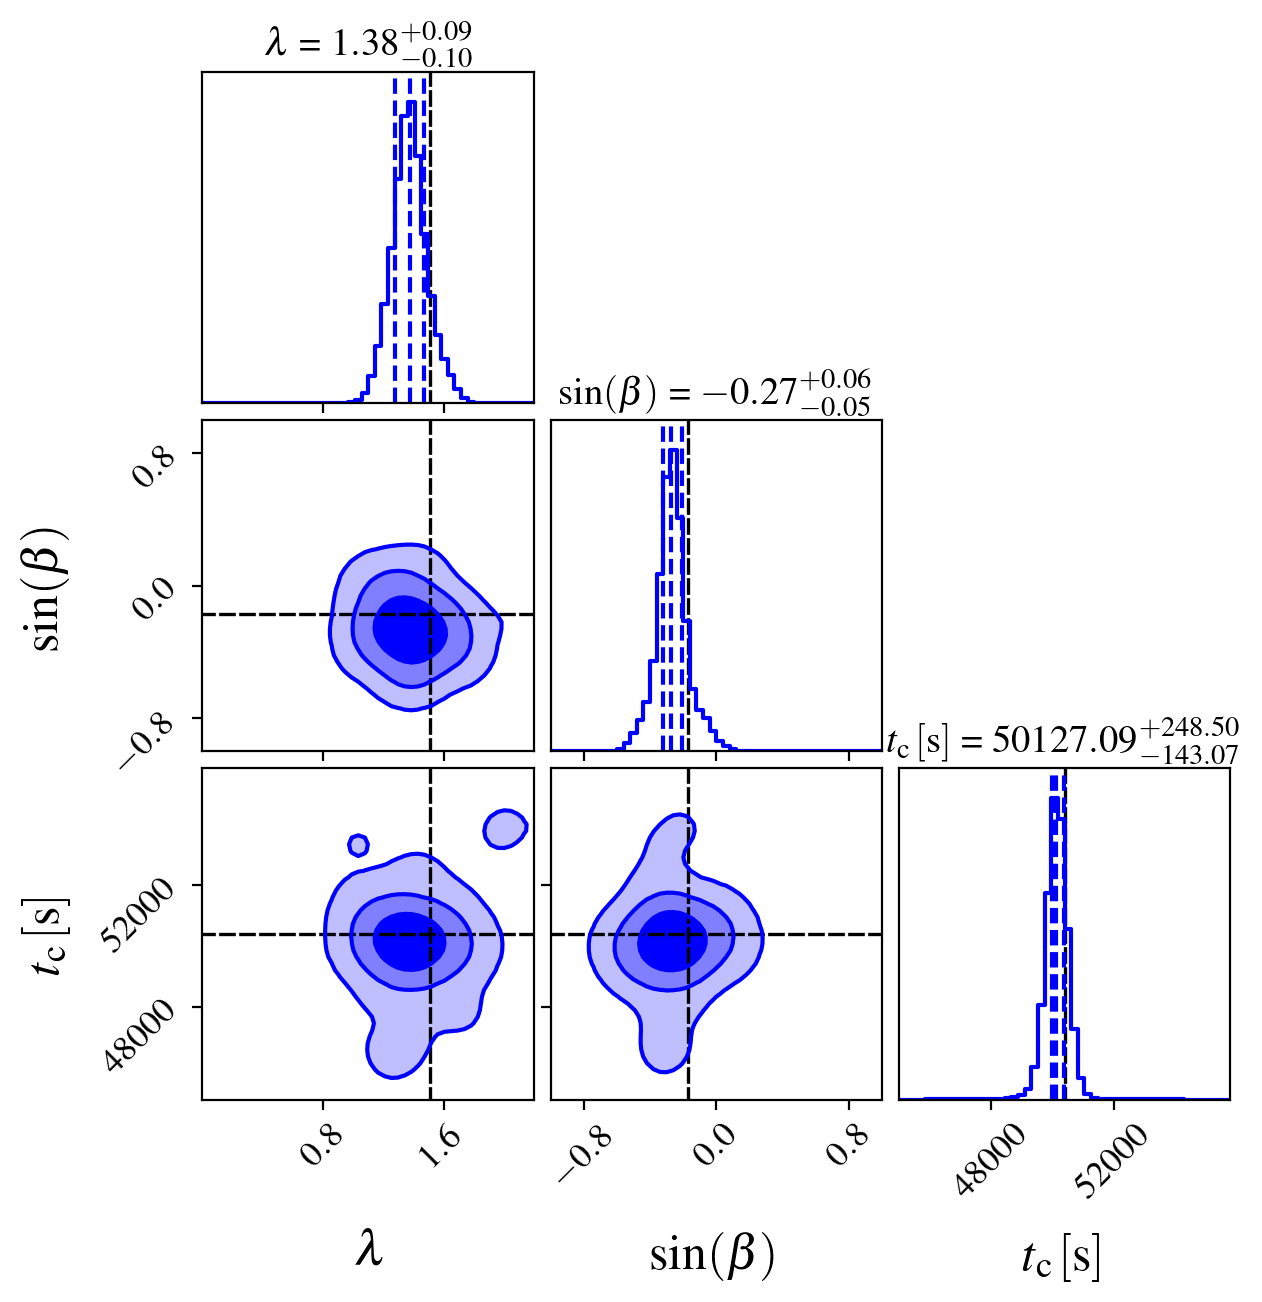

In [11]:
df_post_burnin_lam_beta_tc = df_bruh[["$\\lambda$", "$\\sin(\\beta)$", "$t_{\\mathrm{c}} \\, [\\mathrm{s}]$"]]
new_injection_parameters = injection_parameters[[7,8,10]]
nparams_3 = 3
fig , axs = plt.subplots(nparams_3,nparams_3, figsize=(6.3,6.3))
for ax in axs.flatten('C'):
    ax.tick_params(which='both',labelsize=13)

## for all ax tick labels, max significant digits = 3, need to set this with rcparams
for i in range(nparams_3):
    axs[i,i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
    axs[i,i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.3f}'))

## for all axes when i==j, draw dashed vline at injection and for i<=j draw dashed vline and hline at injections
for i in range(nparams_3):
    for j in range(nparams_3):
        if i==j:
            axs[i,j].axvline(new_injection_parameters[i], color='k', linestyle=(1,(5,1)), linewidth=1.2)
        if i>j:
            axs[i,j].axvline(new_injection_parameters[j], color='k', linestyle=(1,(5,1)), linewidth=1.2)
            axs[i,j].axhline(new_injection_parameters[i], color='k', linestyle=(1,(5,1)), linewidth=1.2)

## list of fractional/decimal values of 1, 2 and 3 sigma
levels = [0.6827, 0.9545, 0.9973]

ranges_10_3 = np.array([
    (0.0, 2.2),
    (-1.0, 1.0),
    (injection_parameters[-1]-1.5*3600, injection_parameters[-1]+1.5*3600)
])

corner.corner(  
                df_post_burnin_lam_beta_tc.values, 
                labels=["$\\lambda$", "$\\sin(\\beta)$", "$t_{\\mathrm{c}} \\, [\\mathrm{s}]$"], 
                fig=fig,
                show_titles=True,
                title_kwargs={"fontsize":14},
                levels=levels,
                color = 'blue',
                alpha=0.6,
                smooth=2.5,
                labelpad=0.1,
                label_kwargs={"fontsize":18},
                quantiles=[0.16, 0.5, 0.84],
                bins=50,
                fill_contours=True,
                plot_datapoints=False,
                max_n_ticks=3,
                smooth1d=1.2,
                range=ranges_10_3,
                #hist_kwargs={"density": True, "linewidth": 1.5, "histtype": "stepfilled", "alpha": 0.2, },
                    );

# save figure as pdf
#plt.savefig("COMPL_NEW_14_hours/corner_different_inputs_lam_beta_tc.pdf", dpi=300, bbox_inches='tight', pad_inches=0.1)

In [20]:
df_post_burnin_np = df_bruh.to_numpy()
skyloc_2d_marg_params = df_post_burnin_np[:, [7, 8]]
skyloc_2d_marg_params[:, 1] = np.arcsin(skyloc_2d_marg_params[:, 1])

In [21]:
### Create an aitoff projection map and plot on the sky
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import fits
from ligo.skymap import plot, kde, postprocess, io
import healpy as hp

In [22]:
skypos_ = kde.Clustered2DSkyKDE(skyloc_2d_marg_params, jobs=8)

  0%|          | 0/200 [00:00<?, ?it/s]

In [23]:
heatmap = skypos_.as_healpix()

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3072 [00:00<?, ?it/s]

  0%|          | 0/3072 [00:00<?, ?it/s]

  0%|          | 0/3072 [00:00<?, ?it/s]

  0%|          | 0/3072 [00:00<?, ?it/s]

  0%|          | 0/3072 [00:00<?, ?it/s]

  0%|          | 0/3072 [00:00<?, ?it/s]

  0%|          | 0/3072 [00:00<?, ?it/s]

  0%|          | 0/3072 [00:00<?, ?it/s]

  0%|          | 0/3072 [00:00<?, ?it/s]

In [24]:
#io.write_sky_map("skymap_COMPLETELY_NEW_14_hours.fits", heatmap, nest=None)

io.write_sky_map("modified_skymap_COMPLETELY_NEW_14_hours.fits", heatmap, nest=None)

In [73]:
skymap, metadata = io.read_sky_map("modified_skymap_COMPLETELY_NEW_14_hours.fits", nest=None)

In [82]:
skymap, metadata = io.read_sky_map("modified_skymap_COMPLETELY_NEW_14_hours.fits", nest=None)
nside = hp.npix2nside(len(skymap))

deg2perpix = hp.nside2pixarea(nside, degrees=True)
probperdeg2 = skymap / deg2perpix


In [83]:
pix_scale = 0.1 * u.deg
smooth = 20 * pix_scale

In [84]:
## single colour alpha gradient cmap
cmap = plt.get_cmap('viridis', 3)  # 'viridis
colors = [cmap(i) for i in range(cmap.N)]

/opt/anaconda3/envs/lisa_env/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:258: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = super().contour(*args, **kwargs)


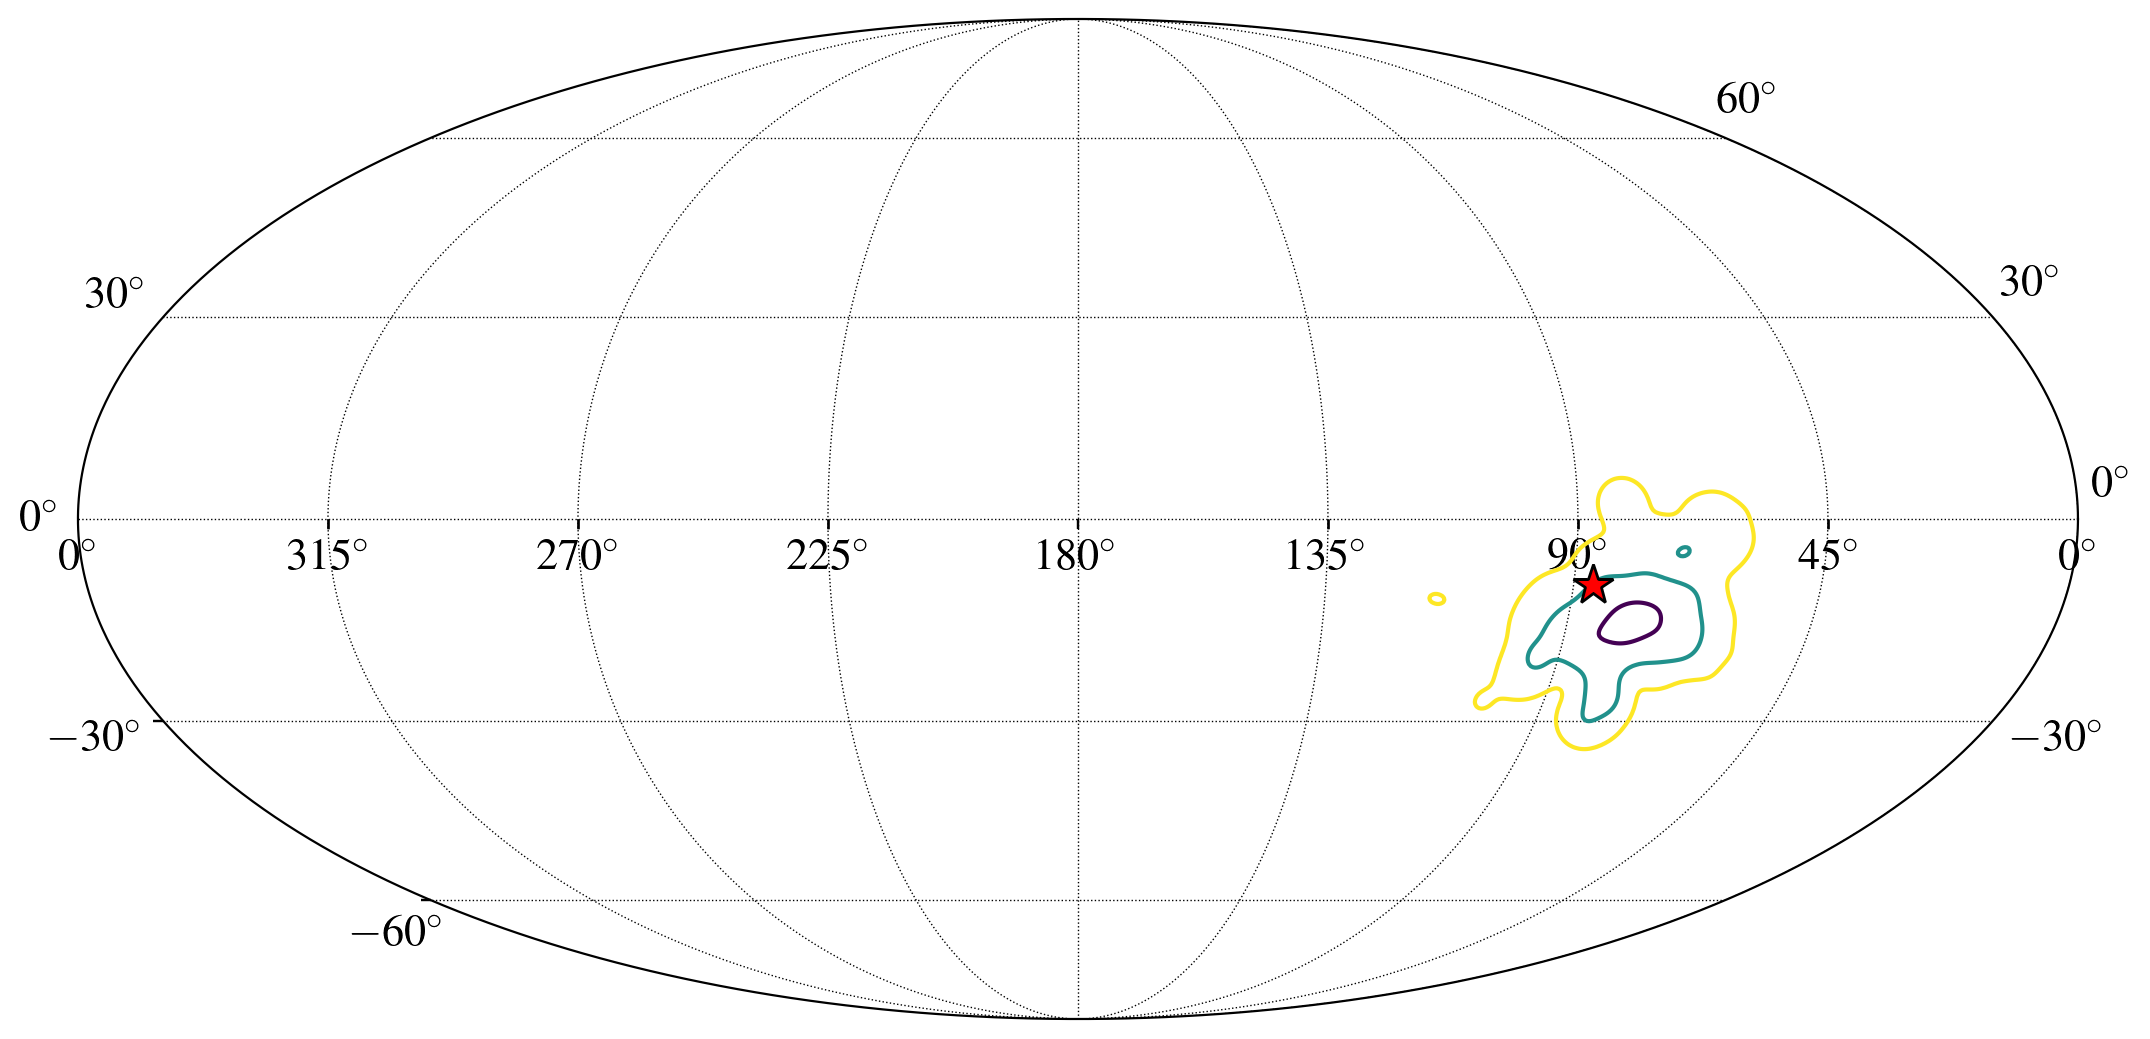

In [85]:
plt.figure(figsize=(10, 6))
center = coord.SkyCoord(
    dec = injection_parameters[8] * u.rad,
    ra = injection_parameters[7] * u.rad
)

ax = plt.axes(
    [0, 0, 1, 1],
    projection = "astro degrees mollweide",
    
)

ax.grid()

confidence_levels = 100 * postprocess.find_greedy_credible_levels(skymap)
contours = ax.contour_hpx(
    (confidence_levels, 'ICRS'),
    nested = metadata['nest'],
    linewidth = 3,
    levels = [68.27, 95.45, 99.73], 
    smooth = smooth,
    colors = colors,
)

ax.plot_coord(center, '*', markeredgecolor='k', color = 'red', markersize=15,)



/opt/anaconda3/envs/lisa_env/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:258: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = super().contour(*args, **kwargs)


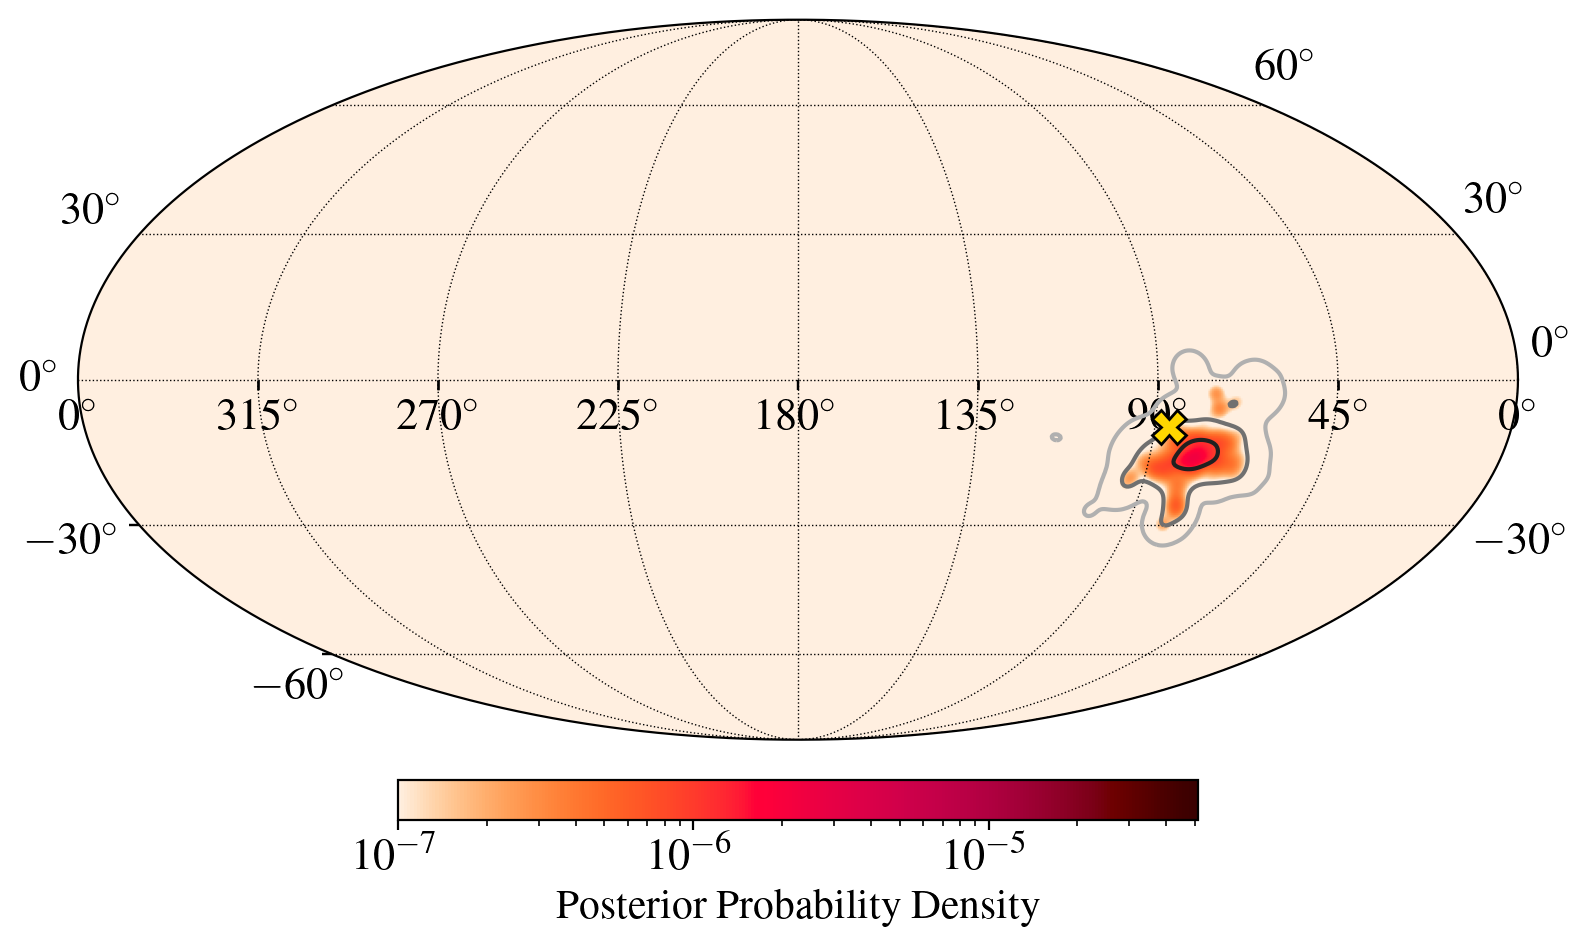

In [94]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from astropy import units as u, coordinates as coord

plt.figure(figsize=(10, 4))
ax = plt.axes([0, 0, 1, 1], projection="astro degrees mollweide")
ax.grid()

center = coord.SkyCoord(
    dec=injection_parameters[8] * u.rad,
    ra=injection_parameters[7] * u.rad
)

# Show full posterior probability gradient
image = ax.imshow_hpx(
    (skymap, 'ICRS'),
    nested=metadata['nest'],
    cmap='cylon',
    norm=LogNorm(vmin=1e-7, vmax=skymap.max(), clip=True),
    smooth=smooth/1.5,
)

# Overlay the 1σ, 2σ, 3σ contours
confidence_levels = 100 * postprocess.find_greedy_credible_levels(skymap)
contours = ax.contour_hpx(
    (confidence_levels, 'ICRS'),
    nested=metadata['nest'],
    linewidth=2,
    levels=[68.27, 95.45, 99.73],
    smooth=smooth,
    colors = ['#202020', '#707070', '#B0B0B0']
)

# Mark true sky location
ax.plot_coord(center, 'X', markeredgecolor='k', color='gold', markersize=12)

# Add colorbar
cb = plt.colorbar(image, ax=ax, orientation='horizontal', pad=0.05, fraction=0.05)
cb.set_label('Posterior Probability Density', fontsize=15)

plt.savefig(
    "COMPL_NEW_14_hours/skymap.pdf",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.1
)
plt.show()


/opt/anaconda3/envs/lisa_env/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:258: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = super().contour(*args, **kwargs)


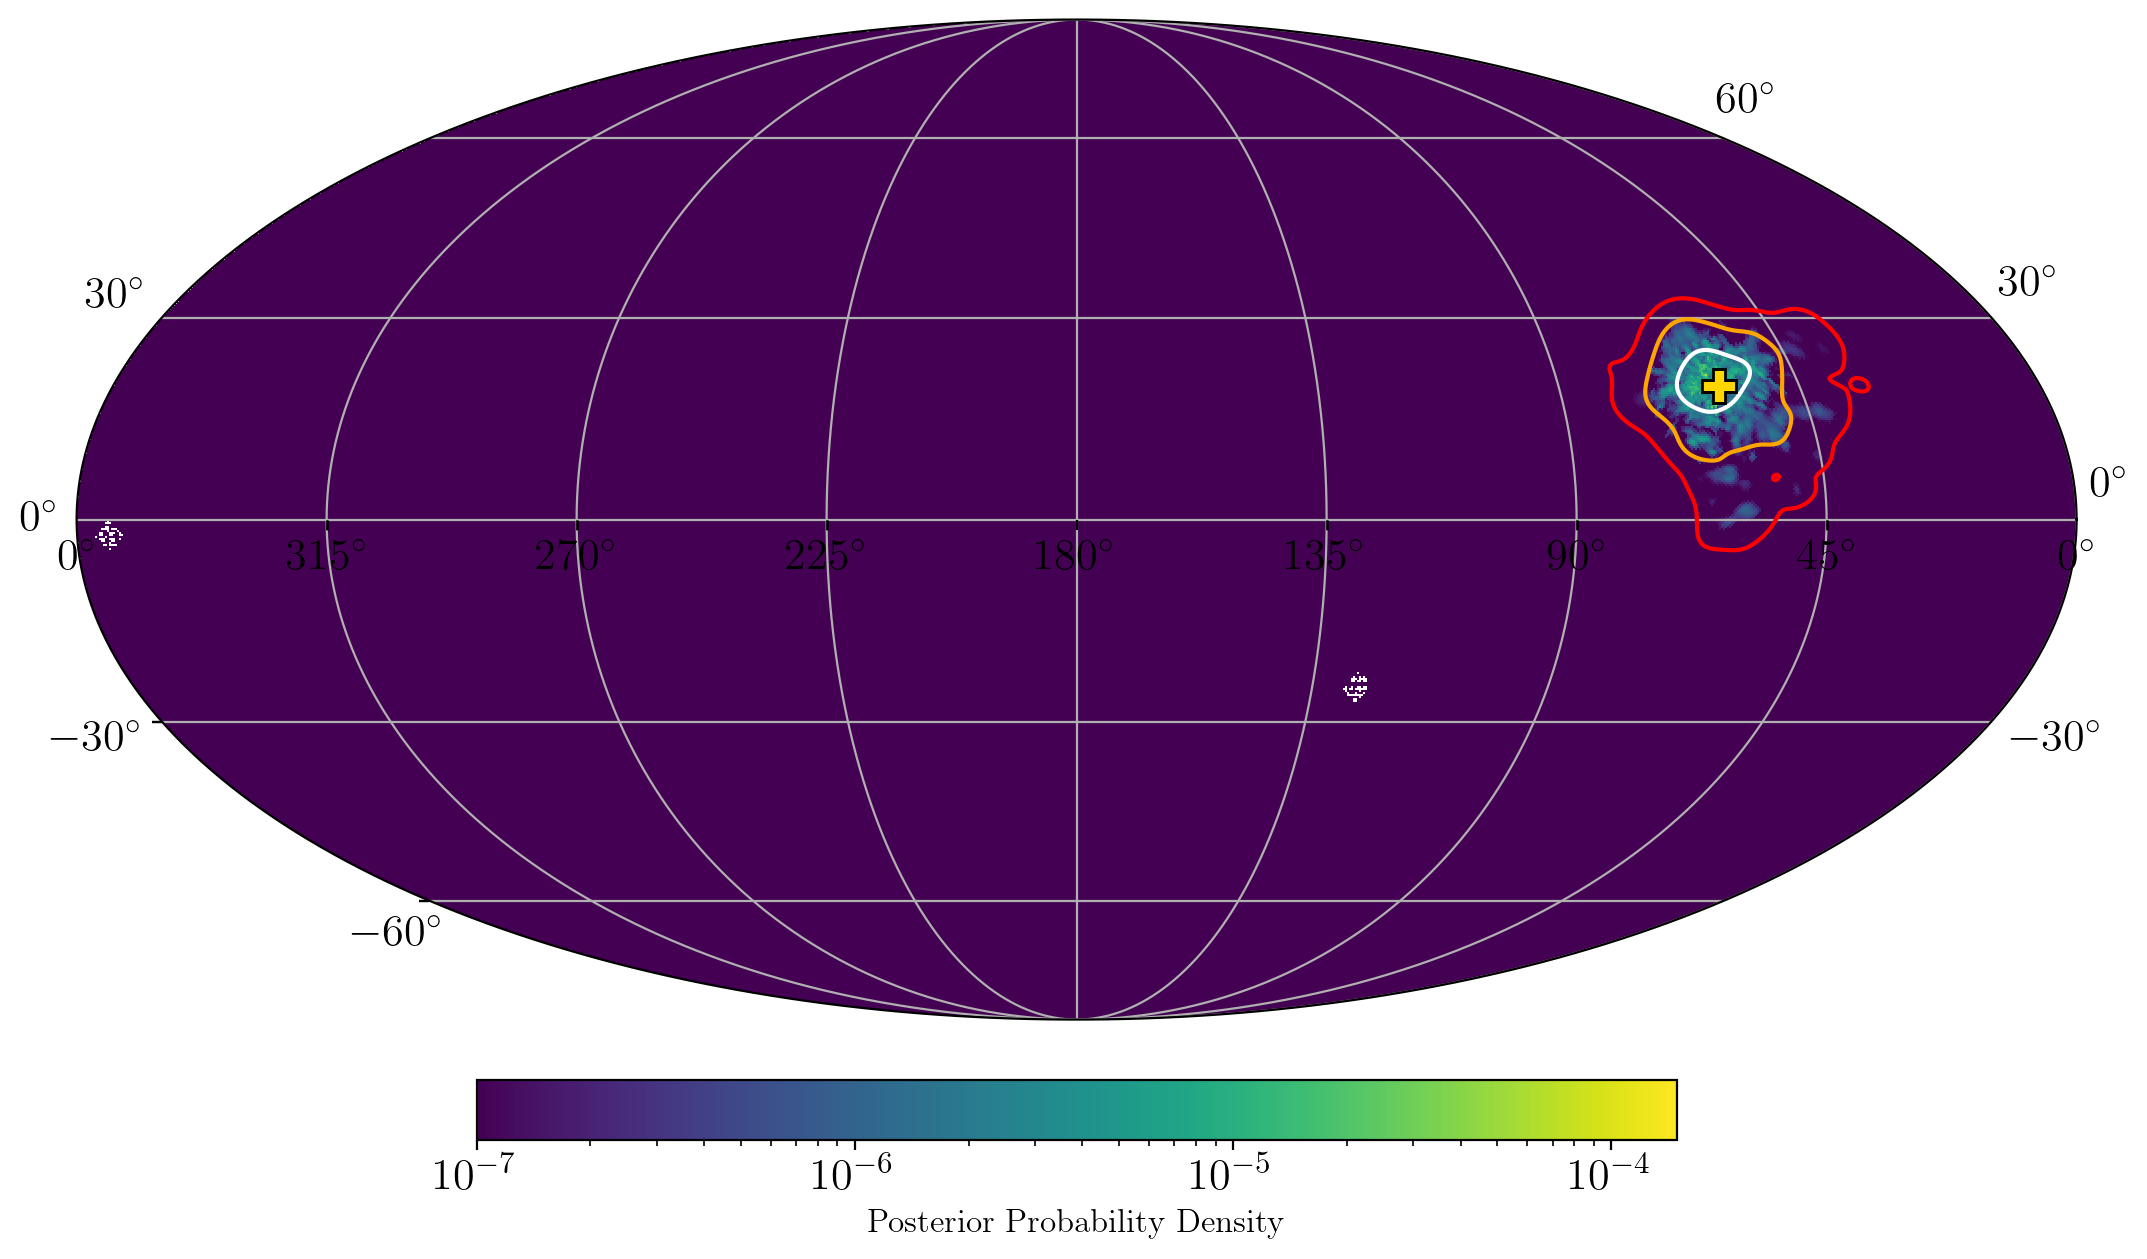

In [55]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from astropy import units as u, coordinates as coord
from ligo.skymap import postprocess
import numpy as np

plt.figure(figsize=(10, 6))
ax = plt.axes([0, 0, 1, 1], projection="astro degrees mollweide")
ax.grid()

# Fix zeros / NaNs
safe_skymap = np.copy(skymap)
safe_skymap[~np.isfinite(safe_skymap)] = 0
safe_skymap[safe_skymap <= 0] = 1e-1000




# Plot posterior probability density with official LIGO color scale
image = ax.imshow_hpx(
    (safe_skymap, 'ICRS'),
    nested=metadata['nest'],
    cmap='OrRd',
    norm=LogNorm(vmin=1e-7, vmax=safe_skymap.max()),
)

# Compute and plot contours
confidence_levels = 100 * postprocess.find_greedy_credible_levels(safe_skymap)
ax.contour_hpx(
    (confidence_levels, 'ICRS'),
    nested=metadata['nest'],
    linewidth=2,
    levels=[68.27, 95.45, 99.73],
    colors=['white', 'orange', 'red'],  
    smooth=smooth,
)

# Mark true sky location with a different symbol
center = coord.SkyCoord(
    dec=injection_parameters[8] * u.rad,
    ra=injection_parameters[7] * u.rad
)
ax.plot_coord(center, 'P', markeredgecolor='k', color='gold', markersize=12)

# Add colorbar
cb = plt.colorbar(image, ax=ax, orientation='horizontal', pad=0.05, fraction=0.05)
cb.set_label('Posterior Probability Density', fontsize=12)

plt.savefig("10hours_different_inputs/skymap.pdf", dpi=300)
plt.show()


In [90]:
credible_levels = postprocess.find_greedy_credible_levels(skymap)
area_90 = np.sum(credible_levels <= 0.90) * (4 * np.pi / skymap.size) * (180/np.pi)**2

# using rubin_fov = 9.6 deg² per field from
# https://rubinobservatory.org/for-scientists/rubin-101/key-numbers
# https://www.spiedigitallibrary.org/conference-proceedings-of-spie/9906/1/Large-Synoptic-Survey-Telescope-mount-final-design/10.1117/12.2232996.short

rubin_fov = 9.6  # deg² per field
n_fields = np.ceil(area_90 / rubin_fov)

print(f"90% credible area = {area_90:.2f} deg²")
print(f"Estimated Rubin pointings (9.6 deg² each): {n_fields:.0f}")


90% credible area = 181.16 deg²
Estimated Rubin pointings (9.6 deg² each): 19


In [91]:
20*9.6

192.0

In [75]:
area_90

np.float64(181.1585416959739)

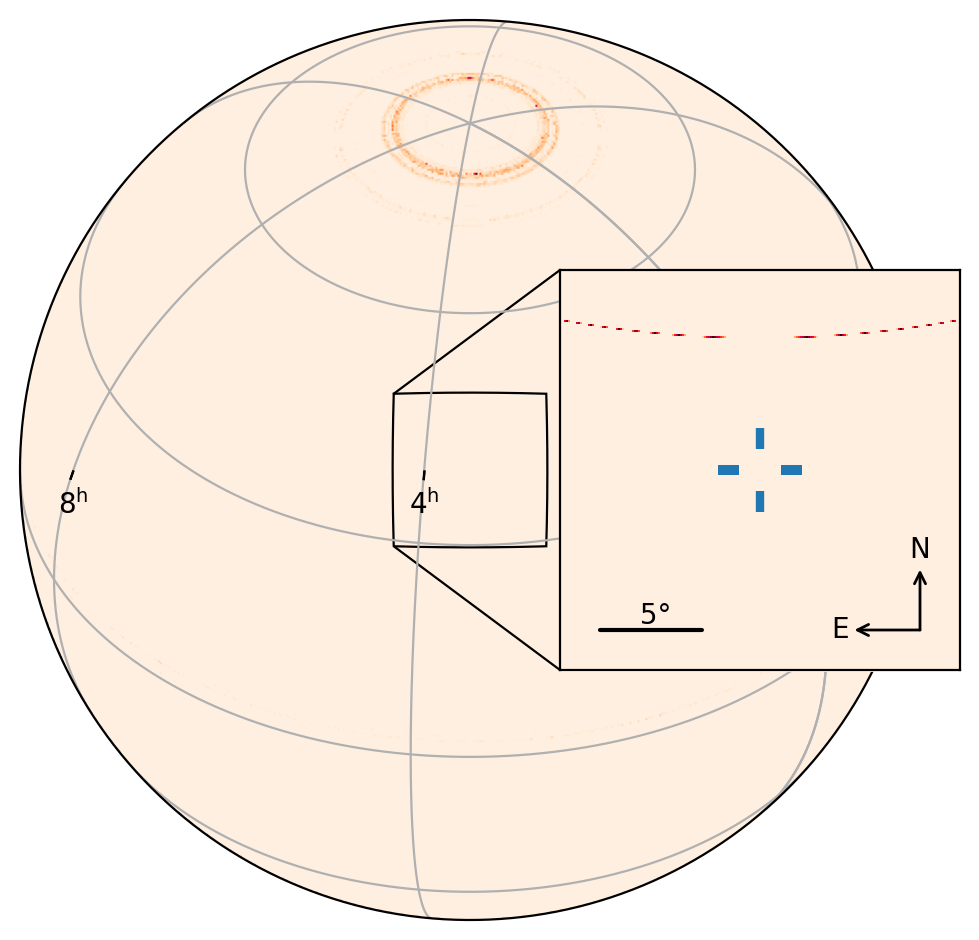

In [ ]:
"""from astropy.coordinates import SkyCoord
import astropy.units as u

import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

# skyloc_2d_marg_params has shape (N, 2) = (lambda, beta) in radians
lam = skyloc_2d_marg_params[:, 0]
beta = skyloc_2d_marg_params[:, 1]

# Convert to SkyCoord and then to ICRS (RA, Dec)
coords = SkyCoord(lam*u.rad, beta*u.rad, frame='barycentrictrueecliptic')
coords_icrs = coords.icrs

ra = coords_icrs.ra.rad
dec = coords_icrs.dec.rad

# Stack back together for KDE
samples_icrs = np.column_stack((ra, dec))
from astropy.coordinates import SkyCoord
from astropy import units as u
from matplotlib import pyplot as plt
import ligo.skymap.plot

# True source location — also convert it from ecliptic to ICRS for marking
true_center = SkyCoord(60*u.deg, 20*u.deg,
                       frame='barycentrictrueecliptic').icrs

fig = plt.figure(figsize=(5, 5), dpi=100)
ax = plt.axes([0.05, 0.05, 0.9, 0.9],
              projection='astro globe',
              center=true_center)

ax_inset = plt.axes([0.59, 0.3, 0.4, 0.4],
                    projection='astro zoom',
                    center=true_center,
                    radius=10*u.deg)

for key in ['ra', 'dec']:
    ax_inset.coords[key].set_ticklabel_visible(False)
    ax_inset.coords[key].set_ticks_visible(False)

ax.grid()
ax.mark_inset_axes(ax_inset)
ax.connect_inset_axes(ax_inset, 'upper left')
ax.connect_inset_axes(ax_inset, 'lower left')
ax_inset.scalebar((0.1, 0.1), 5*u.deg).label()
ax_inset.compass(0.9, 0.1, 0.2)

ax.imshow_hpx(skymap, cmap='cylon')
ax_inset.imshow_hpx(skymap, cmap='cylon')

# Mark your source
ax_inset.plot(true_center.ra.deg, true_center.dec.deg,
              transform=ax_inset.get_transform('world'),
              marker=ligo.skymap.plot.reticle(),
              markersize=30, markeredgewidth=3)
"""

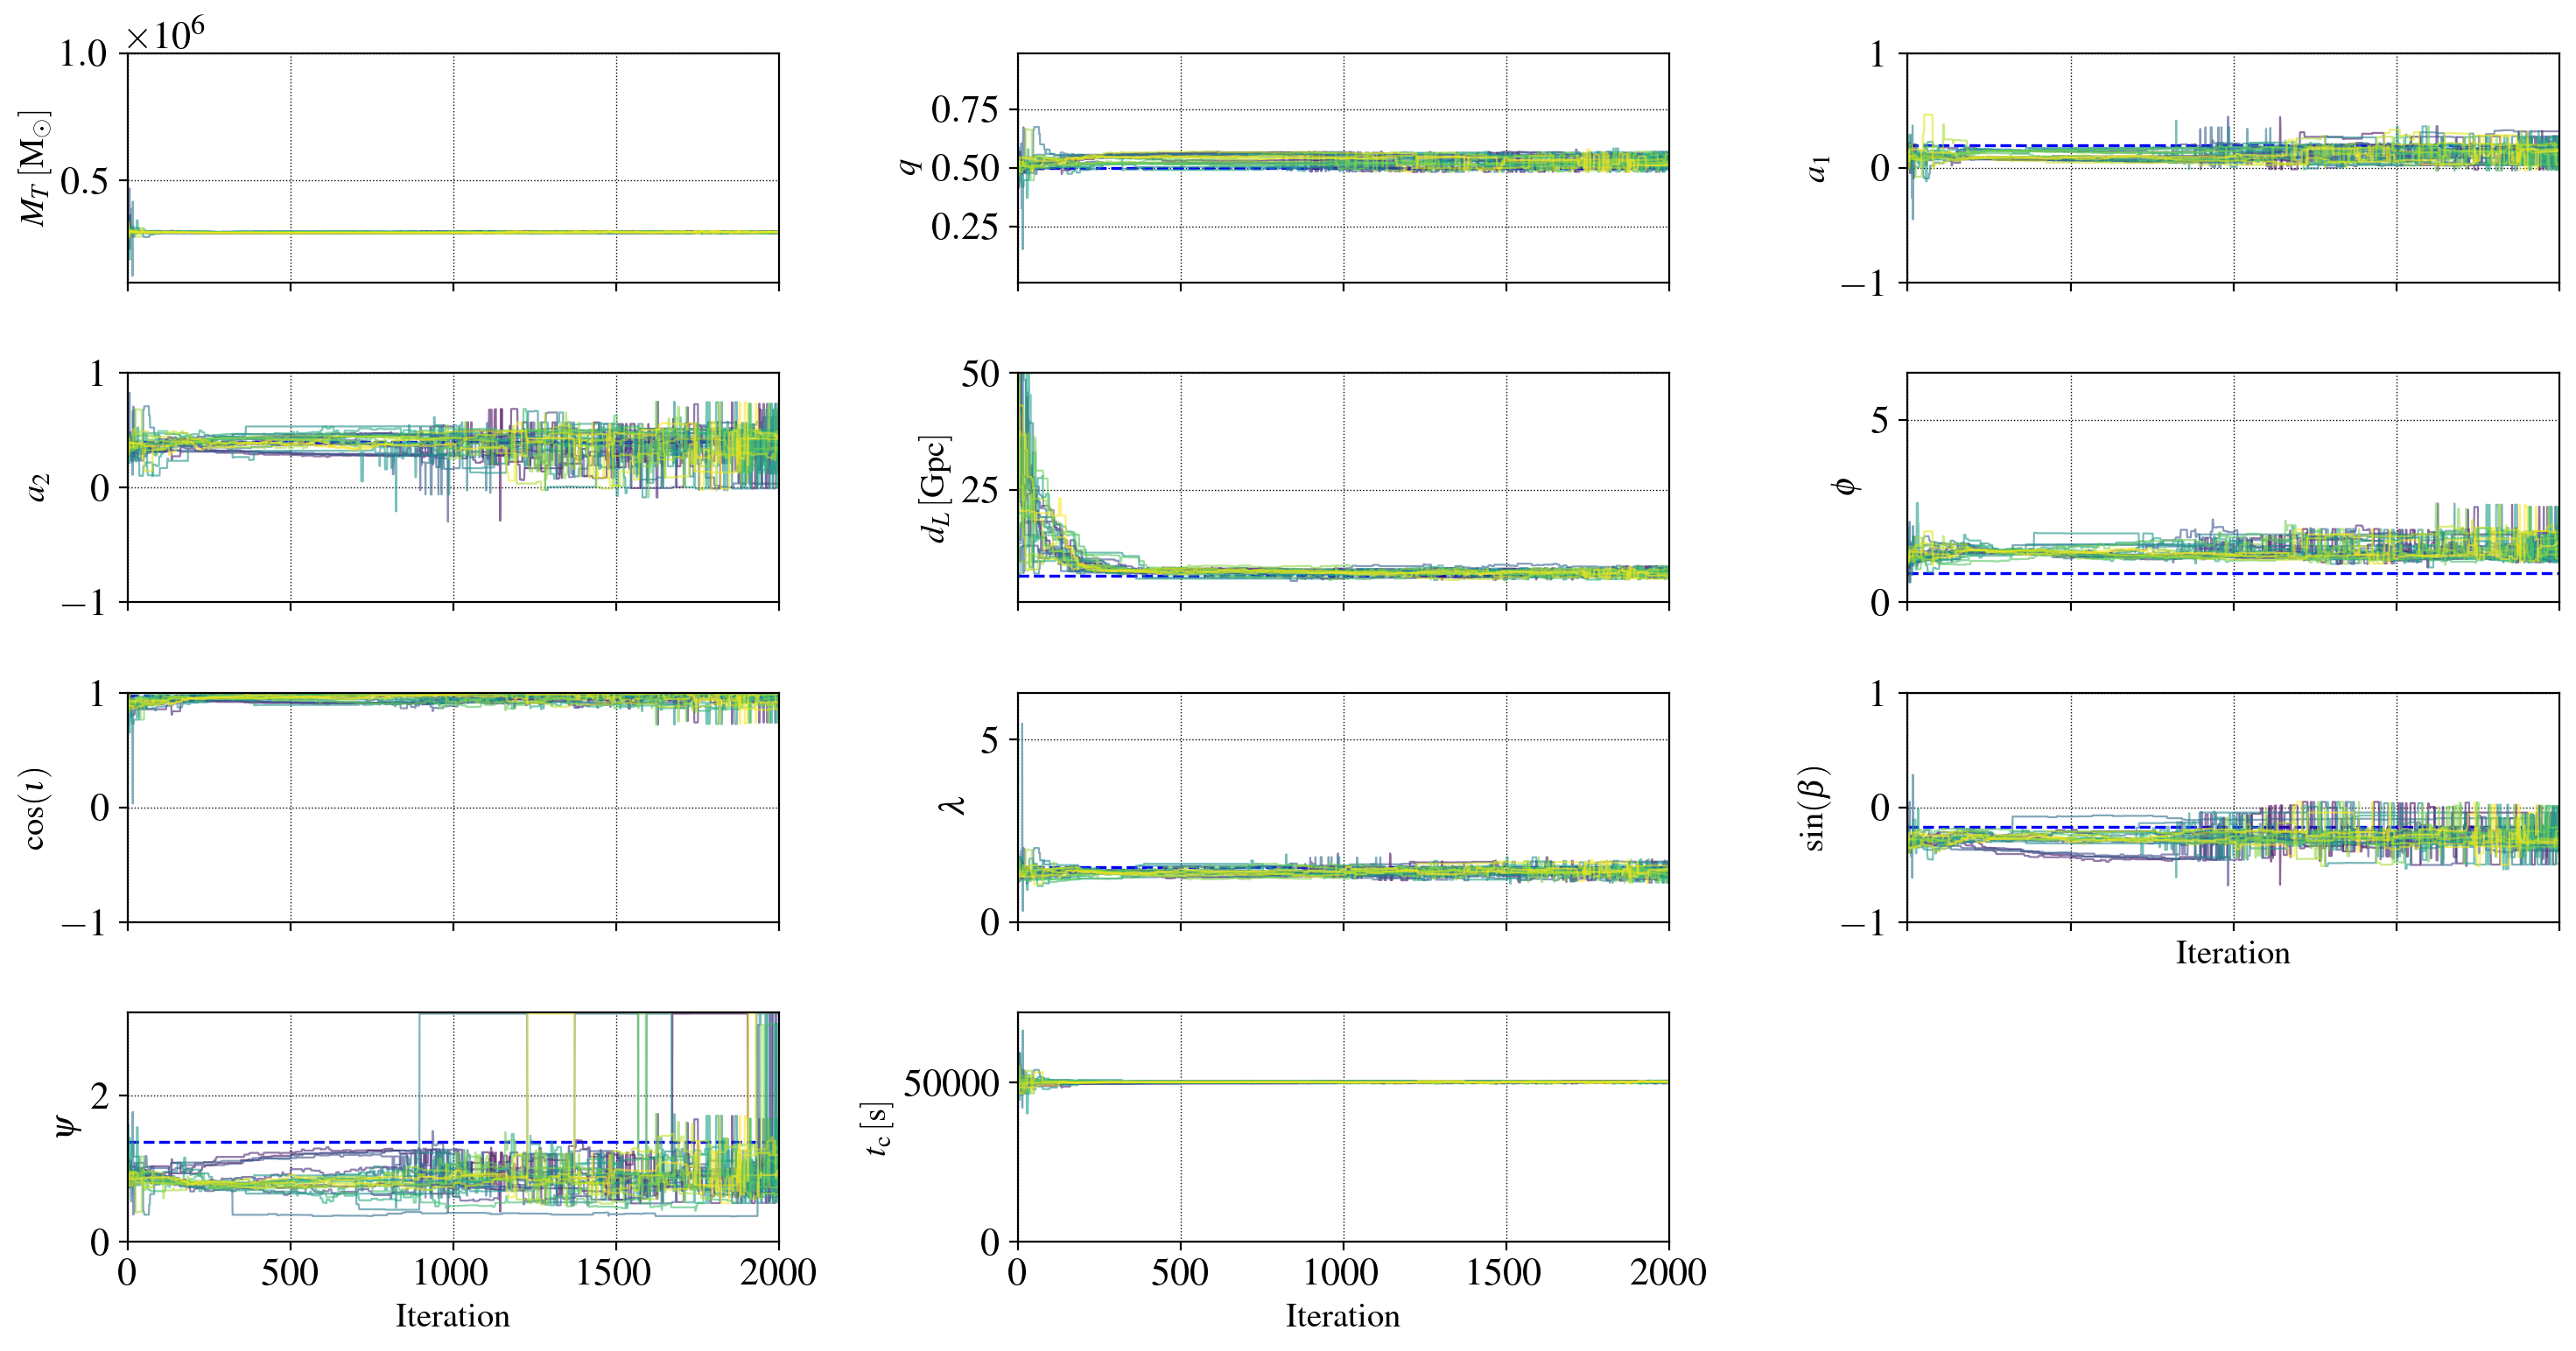

In [93]:
import matplotlib.pyplot as plt
import numpy as np

priors = {"mbh": ProbDistContainer({
        0 : uniform_dist(1e5, 1e6),                  # mT = m1 + m2
        1 : uniform_dist(0.01, 0.99),                # q = m2/m1
        2 : uniform_dist(-1, +1),                    # a1
        3 : uniform_dist(-1, +1),                    # a2
        4 : uniform_dist(1, 50),                     # dist in Mpc
        5 : uniform_dist(0, 2*np.pi),                # phi_ref
        6 : uniform_dist(-1, 1),                     # cos(inc)
        7 : uniform_dist(0.0, 2 * np.pi),            # lam
        8 : uniform_dist(-1.0, 1.0),                 # sin(beta)
        9 : uniform_dist(0.0, np.pi),                # psi
        10: uniform_dist(0, max_time-cutoff_time),     # t_ref
    })}

plotting_walkers_range = nwalkers
colors = cm.viridis(np.linspace(0, 1, plotting_walkers_range))

# Choose grid layout (adjust depending on ndims)
ncols = 3
nrows = int(np.ceil(ndims / ncols))

fig, ax = plt.subplots(nrows, ncols, figsize=(15, 2 * nrows), sharex=True)
fig.subplots_adjust(hspace=0.1, wspace=0.1)

# Flatten the axes array for easy iteration
ax = ax.flatten()

walkers_bruh = bruh.copy()
walkers_bruh[:, 0, :, :, 10] = walkers_bruh[:, 0, :, :, 10] - cutoff_time

for i in range(ndims):
    ax[i].axhline(injection_parameters[i], color='blue', linestyle='--', linewidth=1.2, label='Injection')
    for walk in range(plotting_walkers_range):
        ax[i].plot(
            walkers_bruh[:, 0, walk, :, i].flatten(),
            color=colors[walk],
            alpha=0.6,
            linewidth=0.8
        )
    ax[i].set_ylabel(param_labels[i], fontsize=14)
    ax[i].set_ylim(priors["mbh"].priors_in[i].min_val, priors["mbh"].priors_in[i].max_val)
    ax[i].set_xlim(0, nsteps)
    ax[i].grid(True)

# Hide unused subplots if ndims < nrows * ncols
for j in range(ndims, nrows * ncols):
    fig.delaxes(ax[j])

# Add common X label
# Add "Step" label only to the bottommost *existing* subplot in each column
for col in range(ncols):
    # Find all row indices for this column
    col_indices = [r * ncols + col for r in range(nrows)]
    # Keep only those that exist
    col_indices = [idx for idx in col_indices if idx < ndims]
    if col_indices:  # if column has any valid subplot
        bottom_idx = col_indices[-1]
        ax[bottom_idx].set_xlabel("Iteration", fontsize=14)

# plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.tight_layout()
plt.savefig(
    "COMPL_NEW_14_hours/trace_walkers_inputs.pdf",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.1
)
plt.show()

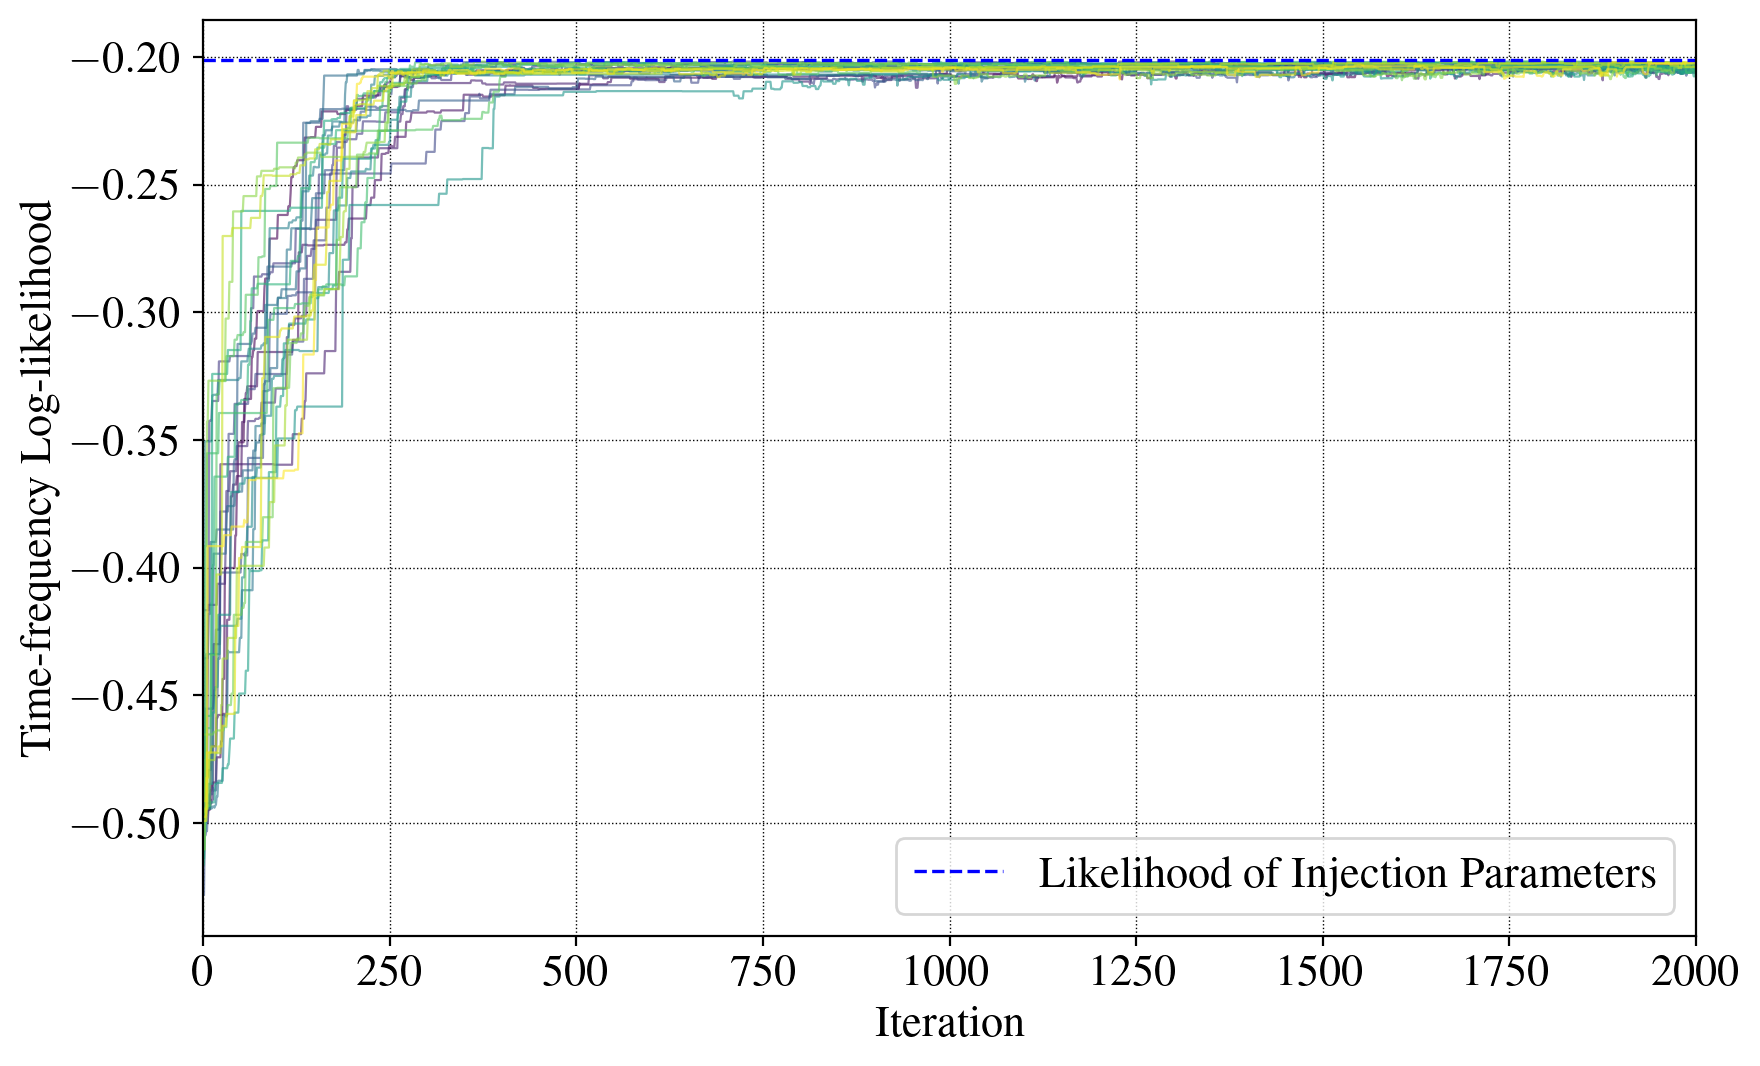

In [69]:
log_like_samples = np.load(f"../mcmc_results/COMPLETELY_NEW_INPUTS/mcmc_loglike_14hours_2000_002.npy") 
log_like_samples = np.load(f"../mcmc_results/COMPLETELY_NEW_INPUTS/new_original_mcmc_loglike_14hours_2000_002.npy") 

for i in range(nwalkers):
    plt.plot(np.arange(1, log_like_samples.shape[0]+1), log_like_samples[:,0,i]/analysis.dt, 
             #label=f"Walker {i+1}", 
             color=colors[i], alpha=0.6, linewidth=0.8)

# plt.axhline(analysis.calculate_time_frequency_likelihood(*parameters, waveform_kwargs=waveform_kwargs)/analysis.dt , 
#             color='blue', linestyle='--', linewidth=1.2, label="Likelihood of Injection Parameters")

plt.axhline(-710.6684357823158/analysis.dt ,
            color='blue', linestyle='--', linewidth=1.2, label="Likelihood of Injection Parameters")
plt.xlabel("Iteration")
plt.ylabel("Time-frequency Log-likelihood")
plt.grid('True')
plt.legend( loc='lower right')
plt.xlim(0, nsteps)
plt.show()


In [ ]:
#np.mean(bruh[0, :, :, :, 7].flatten())

np.float64(1.3594856771061412)

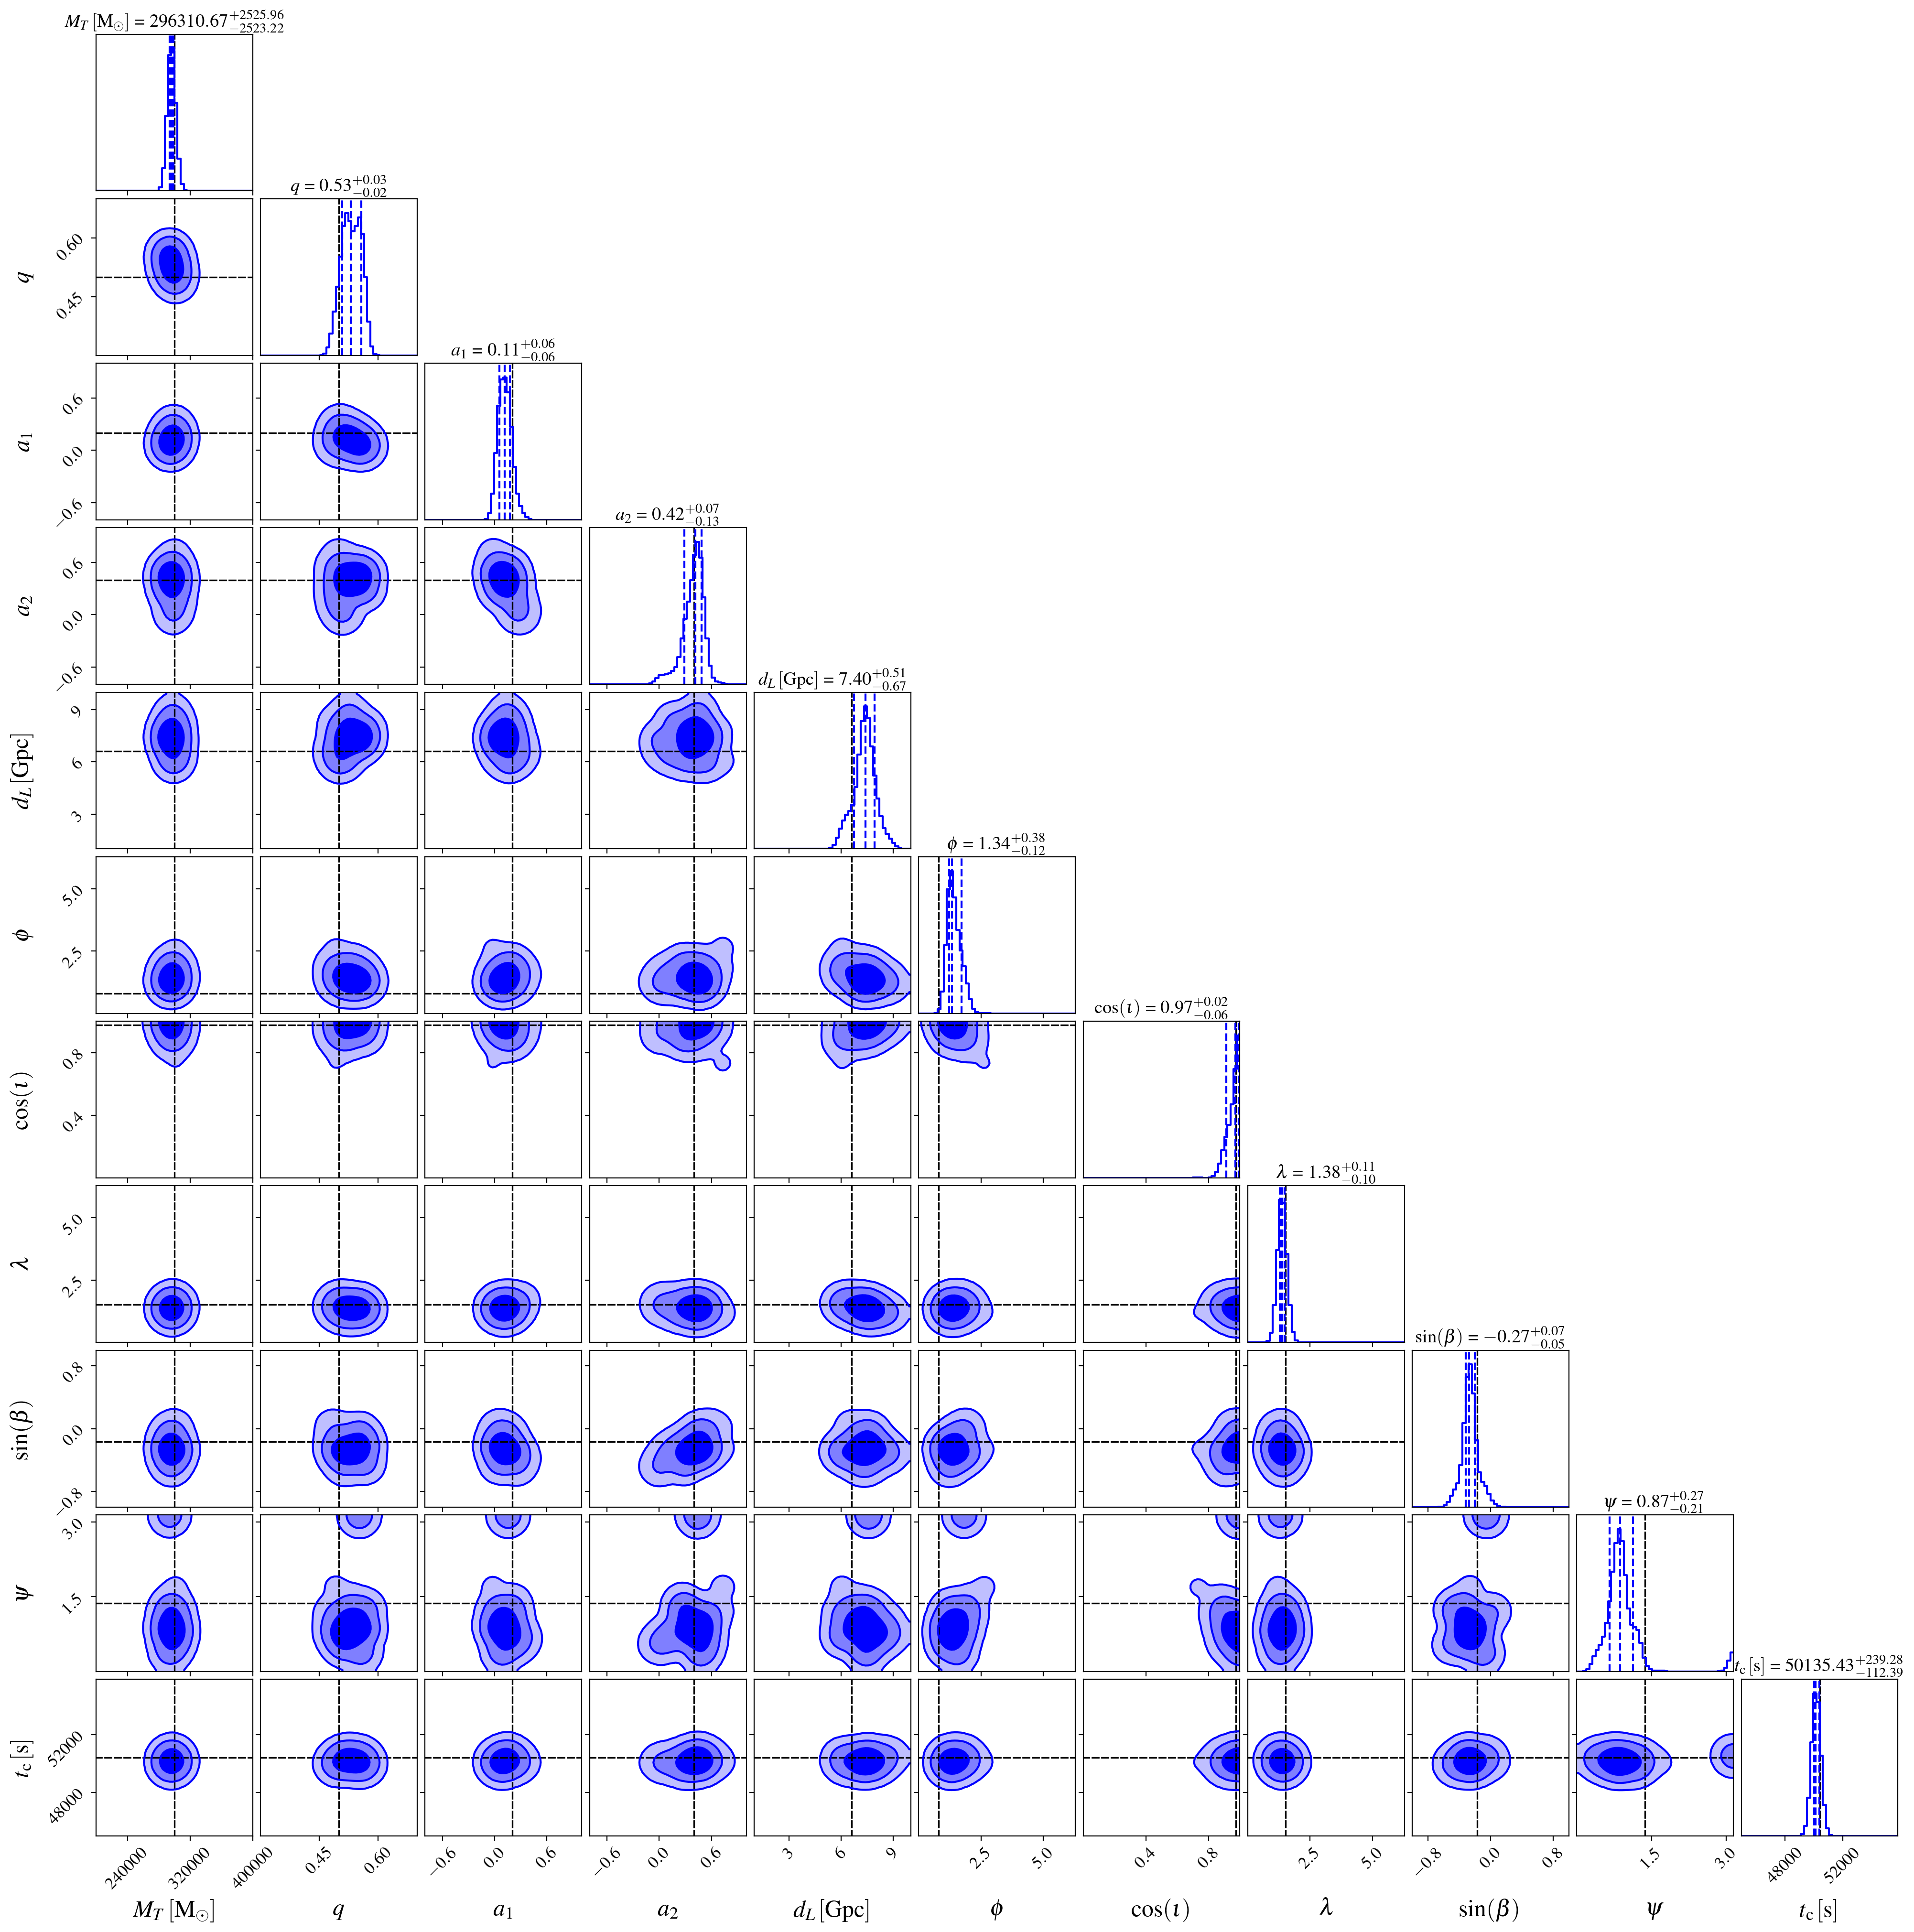

In [71]:
bruh_NEW = np.load(f"../mcmc_results/COMPLETELY_NEW_INPUTS/new_original_mcmc_14hours_2000_002.npy")
#bruh_NEW = np.load(f"mcmc_results/higher_masses/mcmc_high_masses.npy")
injection_parameters = np.array([m1+m2, m2/m1, a1, a2, dist / (PC_SI * 1e9), phi_ref, np.cos(inc), lam, np.sin(beta), psi, t_ref-cutoff_time])

burnin = 500
bruh_post_burnin_NEW = bruh_NEW[burnin:]

samples_bruh_NEW = bruh_post_burnin_NEW[:, 0].reshape(-1, 11)
samples_bruh_NEW[:, 10] = samples_bruh_NEW[:, 10] - cutoff_time
df_bruh_NEW = pd.DataFrame(samples_bruh_NEW, columns=param_labels)

nparams = len(param_labels)
fig , axs = plt.subplots(nparams,nparams, figsize=(20,20))
for ax in axs.flatten('C'):
    ax.tick_params(which='both',labelsize=13)

## for all ax tick labels, max significant digits = 3, need to set this with rcparams
for i in range(nparams):
    axs[i,i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
    axs[i,i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.3f}'))

# for all axes when i==j, draw dashed vline at injection and for i<=j draw dashed vline and hline at injections
for i in range(nparams):
    for j in range(nparams):
        if i==j:
            axs[i,j].axvline(injection_parameters[i], color='k', linestyle=(1,(5,1)), linewidth=1.2)
        if i>j:
            axs[i,j].axvline(injection_parameters[j], color='k', linestyle=(1,(5,1)), linewidth=1.2)
            axs[i,j].axhline(injection_parameters[i], color='k', linestyle=(1,(5,1)), linewidth=1.2)

## list of fractional/decimal values of 1, 2 and 3 sigma
levels = [0.6827, 0.9545, 0.9973]
ranges_plot = np.array([
    (2e5, 4e5),
    (0.3, 0.7),
    (-0.8, 1),
    (-0.8, 1),
    (1.0, 10.0),
    (0, 2*np.pi),
    (0.0, 1.0),
    (0.0, 2*np.pi),
    (-1.0, 1.0),
    (0.0, np.pi),
    (injection_parameters[-1]-1.5*3600, injection_parameters[-1]+1.5*3600)
])
corner.corner(  
                df_bruh_NEW.values, 
                labels=param_labels, 
                fig=fig,
                show_titles=True,
                title_kwargs={"fontsize":14},
                levels=levels,
                color = 'blue',
                alpha=0.6,
                smooth=2.5,
                labelpad=0.1,
                label_kwargs={"fontsize":18},
                quantiles=[0.16, 0.5, 0.84],
                bins=50,
                fill_contours=True,
                plot_datapoints=False,
                max_n_ticks=3,
                smooth1d=1.2,
                range=ranges_plot,
                #hist_kwargs={"density": True, "linewidth": 1.5, "histtype": "stepfilled", "alpha": 0.2, },
                    );

# save figure as pdf
#plt.savefig("COMPL_NEW_14_hours/corner_different_inputs.pdf")

plt.show()